In [1]:
# Import Necessary Libraries
import warnings  # To suppress warnings
import numpy as np  # For numerical operations
import pandas as pd  # For data manipulation and analysis
import seaborn as sns  # For advanced visualizations
import matplotlib.pyplot as plt  # For plotting basic visualizations
from sklearn.preprocessing import OneHotEncoder, LabelEncoder  # For encoding
import os  # For file handling
import category_encoders as ce
# Suppress warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"C:\Users\salma\Desktop\dalya\project healthcare\kaggle supply chain datasets\my work\inventory_kaggle.csv")

In [3]:
df.head()

,Date,Item_ID,Item_Type,Item_Name,Current_Stock,Min_Required,Max_Capacity,Unit_Cost,Avg_Usage_Per_Day,Restock_Lead_Time,Shortage_Risk
0,2024-10-01,105,Consumable,Ventilator,1542,264,1018,4467.55,108,17,True
1,2024-10-02,100,Equipment,Ventilator,2487,656,3556,5832.29,55,12,False
2,2024-10-03,103,Equipment,Surgical Mask,2371,384,5562,16062.98,470,6,True
3,2024-10-04,103,Consumable,Surgical Mask,2038,438,1131,744.10,207,15,True
4,2024-10-05,107,Equipment,IV Drip,2410,338,1013,15426.53,158,12,False


In [4]:
# drop unnecessary or unlogical columns

df.drop(columns=['Item_ID', 'Item_Name'], inplace=True)

df.head()

,Date,Item_Type,Current_Stock,Min_Required,Max_Capacity,Unit_Cost,Avg_Usage_Per_Day,Restock_Lead_Time,Shortage_Risk
0,2024-10-01,Consumable,1542,264,1018,4467.55,108,17,True
1,2024-10-02,Equipment,2487,656,3556,5832.29,55,12,False
2,2024-10-03,Equipment,2371,384,5562,16062.98,470,6,True
3,2024-10-04,Consumable,2038,438,1131,744.10,207,15,True
4,2024-10-05,Equipment,2410,338,1013,15426.53,158,12,False


In [5]:
df.shape

(500, 9)

In [6]:
# Check for Datatypes
print("\nColumn Data Types:")
print(df.dtypes)


Column Data Types:
Date                  object
Item_Type             object
Current_Stock          int64
Min_Required           int64
Max_Capacity           int64
Unit_Cost            float64
Avg_Usage_Per_Day      int64
Restock_Lead_Time      int64
Shortage_Risk           bool
dtype: object


In [7]:
#Check for null values.
null_values = df.isnull().sum()
print(null_values)

Date                 0
Item_Type            0
Current_Stock        0
Min_Required         0
Max_Capacity         0
Unit_Cost            0
Avg_Usage_Per_Day    0
Restock_Lead_Time    0
Shortage_Risk        0
dtype: int64


In [8]:
# Check for Duplicates and Drop Duplicates.
duplicate_count = df.duplicated().sum()
print("\nNumber of Duplicate Rows:", duplicate_count)
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")


Number of Duplicate Rows: 0
No duplicate rows found.


In [9]:
# Convert boolean to integer for shortage column

df['Shortage_Risk'] = df['Shortage_Risk'].astype(int)

df.head()

,Date,Item_Type,Current_Stock,Min_Required,Max_Capacity,Unit_Cost,Avg_Usage_Per_Day,Restock_Lead_Time,Shortage_Risk
0,2024-10-01,Consumable,1542,264,1018,4467.55,108,17,1
1,2024-10-02,Equipment,2487,656,3556,5832.29,55,12,0
2,2024-10-03,Equipment,2371,384,5562,16062.98,470,6,1
3,2024-10-04,Consumable,2038,438,1131,744.10,207,15,1
4,2024-10-05,Equipment,2410,338,1013,15426.53,158,12,0


In [10]:
# view statistical measures for numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Current_Stock,500.0,2458.64400,1390.078133,69.00,1307.7500,2411.50,3719.000,4976.00
Min_Required,500.0,485.98200,292.054772,10.00,215.7500,496.50,734.250,995.00
Max_Capacity,500.0,3288.83400,1602.646278,500.00,1847.7500,3311.00,4696.000,5992.00
Unit_Cost,500.0,10277.32598,5728.684410,4.23,5422.4625,10129.96,15206.315,19984.16
Avg_Usage_Per_Day,500.0,261.80400,143.983318,2.00,150.5000,257.00,392.000,499.00
Restock_Lead_Time,500.0,15.11600,8.610856,1.00,7.0000,16.00,23.000,29.00
Shortage_Risk,500.0,0.64000,0.480481,0.00,0.0000,1.00,1.000,1.00


<h1> Univariate analysis:-

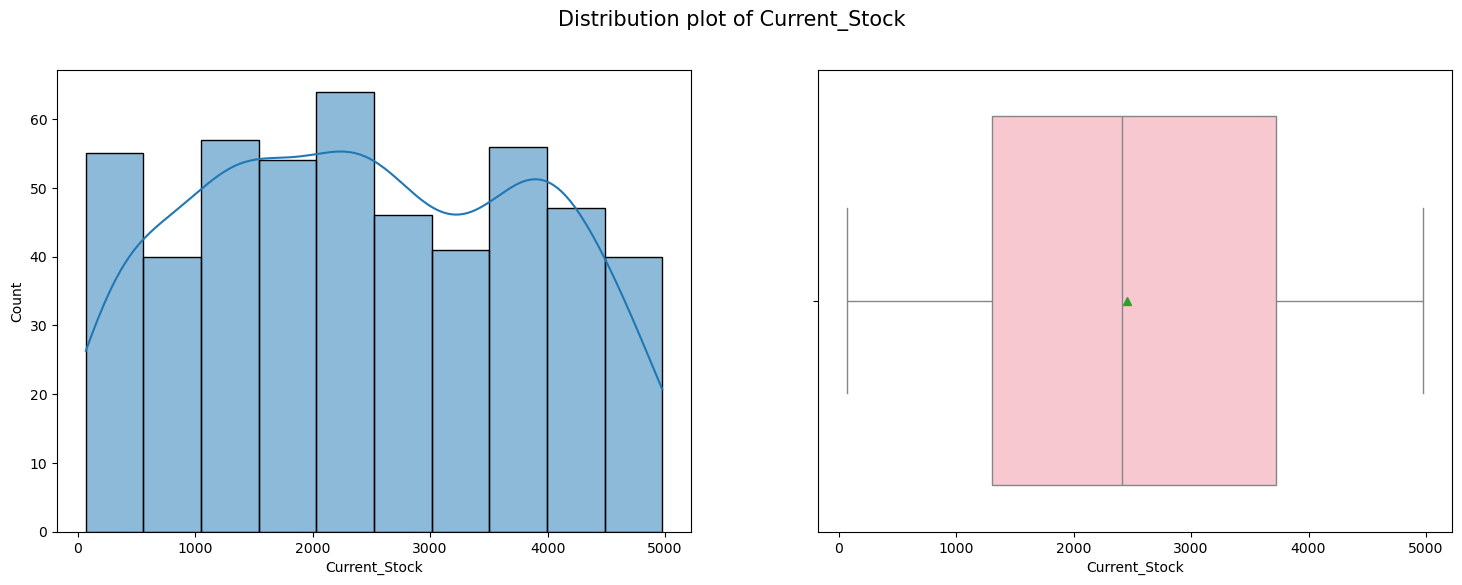

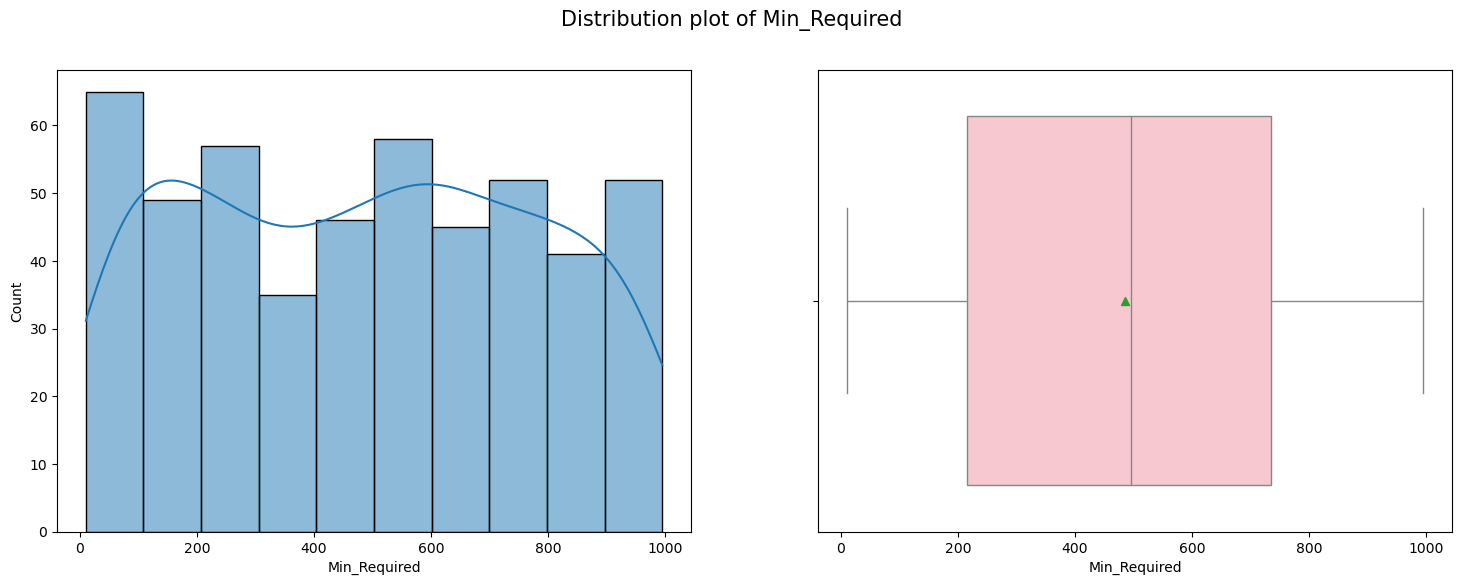

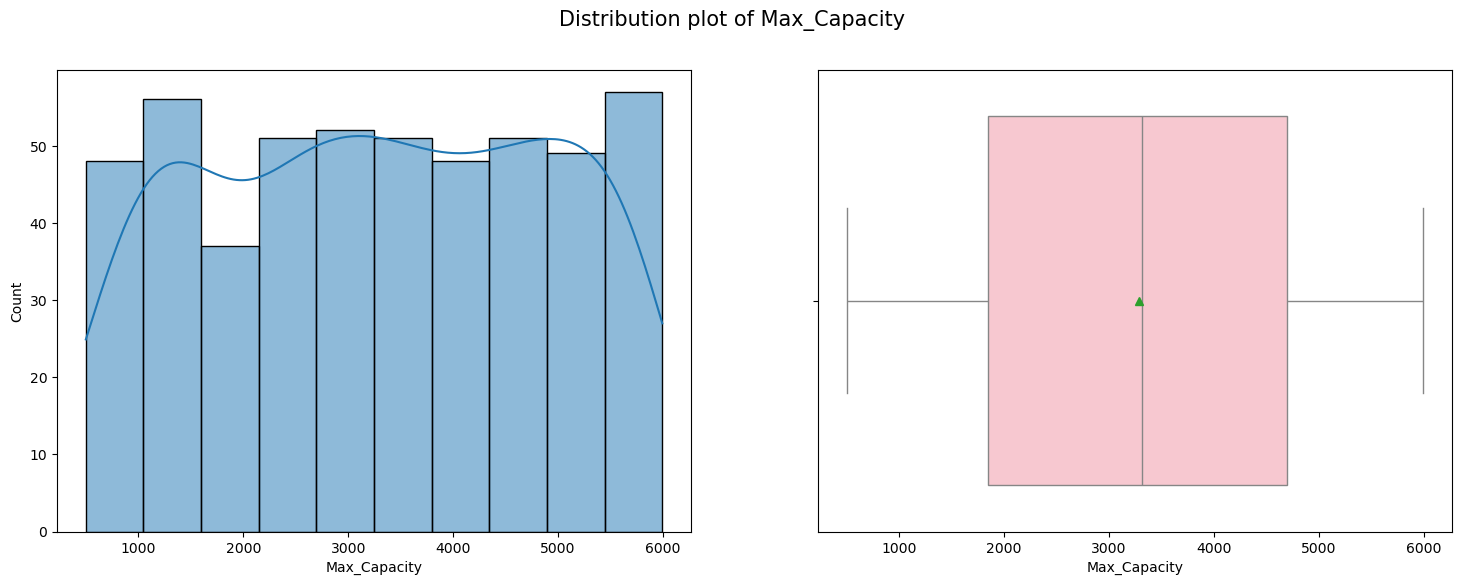

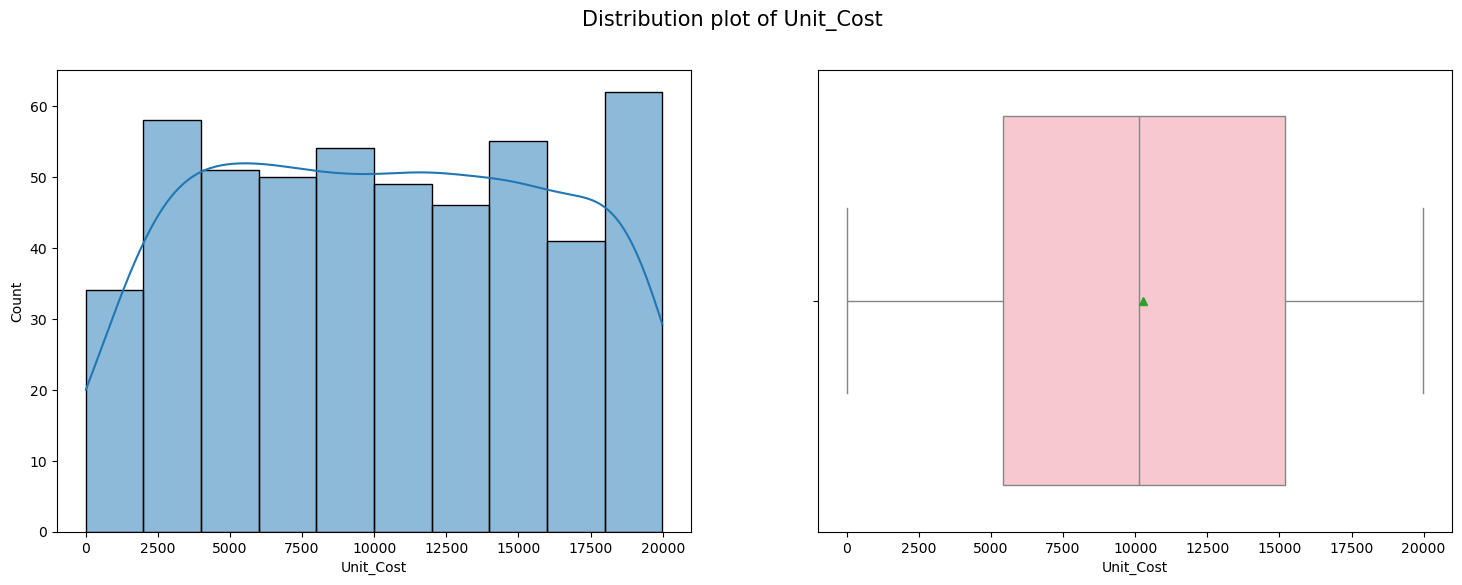

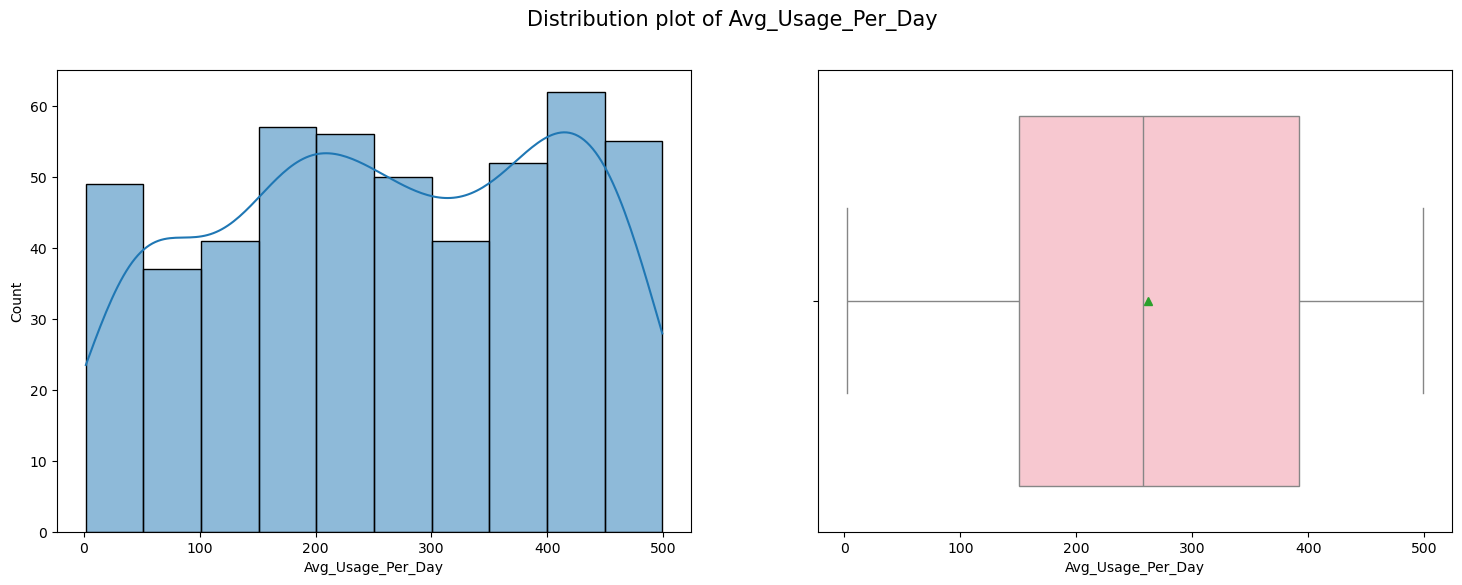

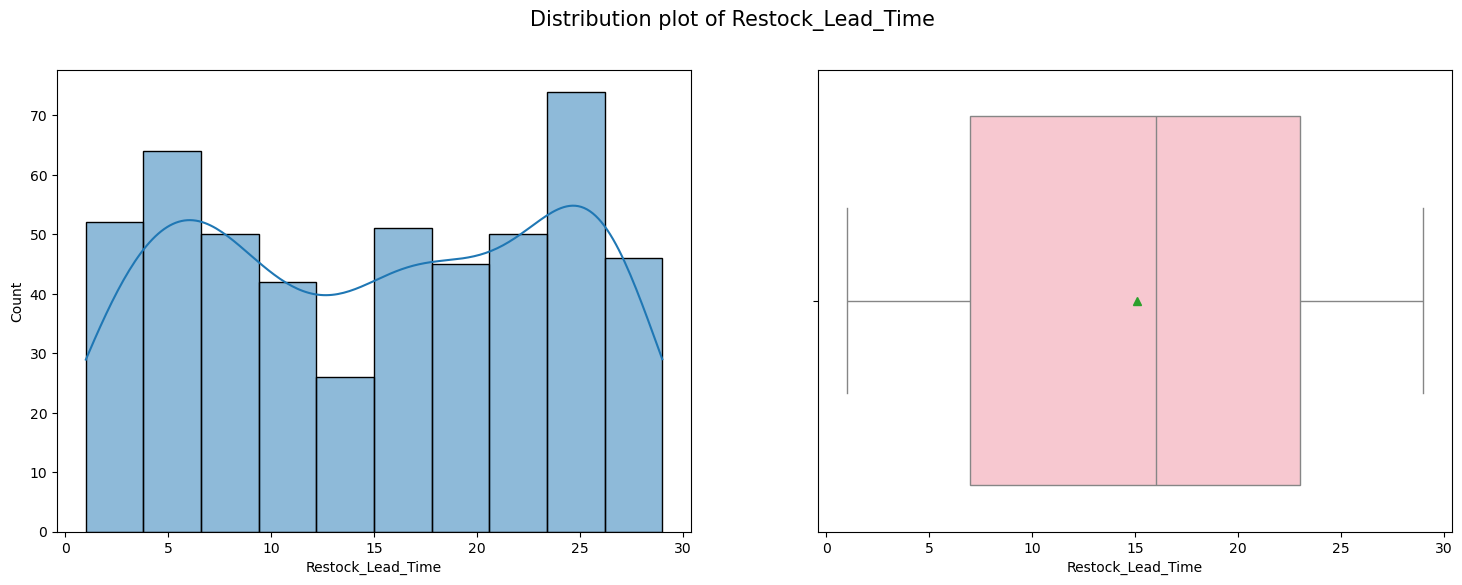

In [11]:
# numerical variables distribution and outliers visualization

for col in df.describe().columns:
    if col != 'Shortage_Risk':
        fig , axes = plt.subplots(nrows=1 , ncols=2 , figsize=(18,6))
        sns.histplot(df[col] , ax = axes[0] , kde = True)
        sns.boxplot(df[col] , ax = axes[1] , orient = 'h' , showmeans = True , color = 'pink')
        fig.suptitle("Distribution plot of " + col , fontsize = 15)
        plt.show()
    

The data appears roughly uniform in most columns indicating well-distribution across different values.

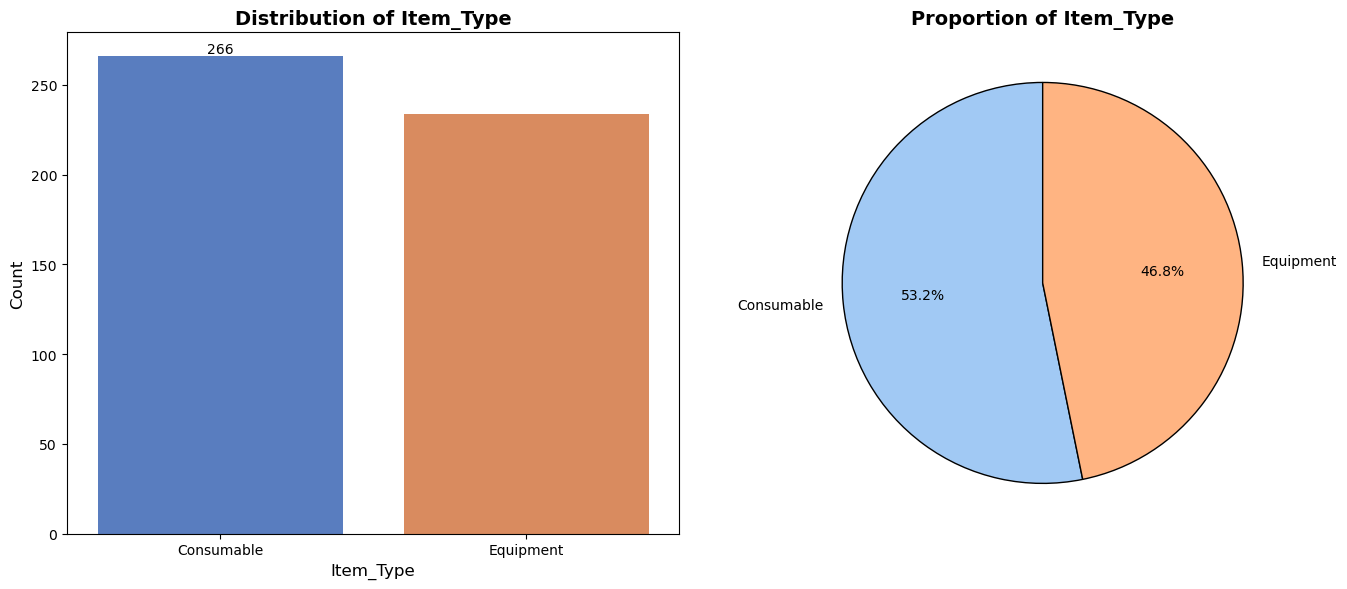

In [12]:
# categorical variable distribution

# Count occurrences of each category
type_counts = df['Item_Type'].value_counts()

# Define a color palette for better visualization
colors = sns.color_palette("pastel")

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Bar Plot ----
sns.barplot(x=type_counts.index, y=type_counts.values, palette="muted", ax=axes[0])
axes[0].set_title('Distribution of Item_Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Item_Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].bar_label(axes[0].containers[0], fmt='%d', fontsize=10)  # Show count labels

# ---- Pie Chart ----
axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Proportion of Item_Type', fontsize=14, fontweight='bold')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

<h1> Target distribution:-

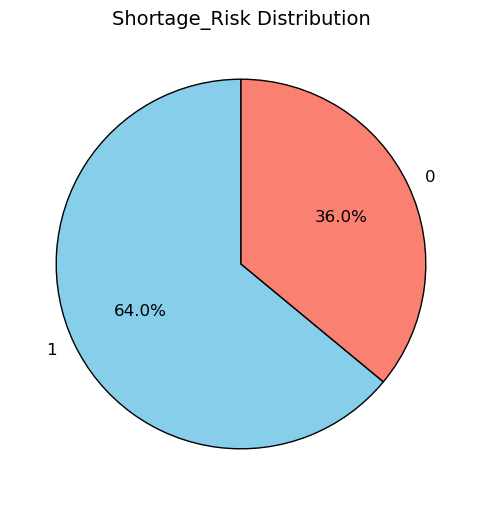

In [13]:
# target variable:-

# Count the occurrences of each category in the 'Shortage_Risk' column
Shortage_Risk_counts = df['Shortage_Risk'].value_counts()

# Define labels and sizes for the pie chart
labels = Shortage_Risk_counts.index.astype(str)  # Convert labels to strings for better visualization
sizes = Shortage_Risk_counts.values  # Extract counts

# Create a pie chart
plt.figure(figsize=(6, 6))  # Set figure size
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'], 
        wedgeprops={'edgecolor': 'black'}, textprops={'fontsize': 12})

# Add a title
plt.title('Shortage_Risk Distribution', fontsize=14)

# Display the chart
plt.show()


It's obvious that our target is imbalanced. I'm going to handle that using class weights inside ensemble learning model. 

<h1> Bivariate analysis:-

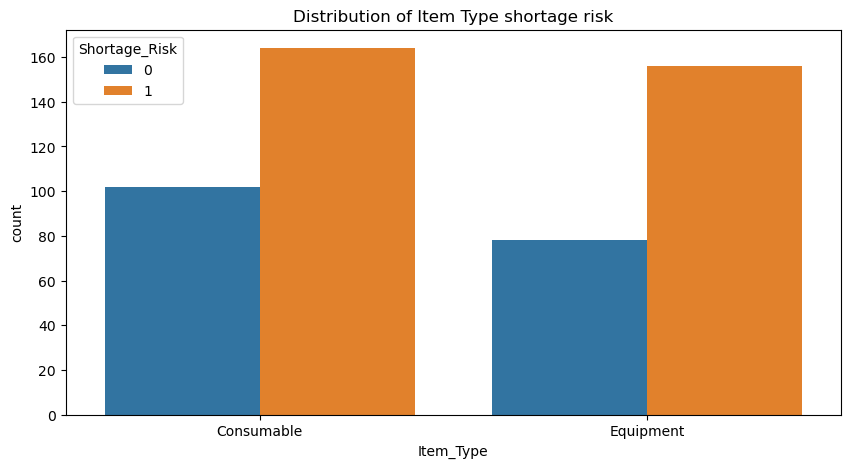

In [14]:
# categorical column with target

plt.figure(figsize=(10, 5))
sns.countplot( x = df['Item_Type'], hue = df['Shortage_Risk'])
plt.title(f"Distribution of Item Type shortage risk")  # Add title
plt.show()

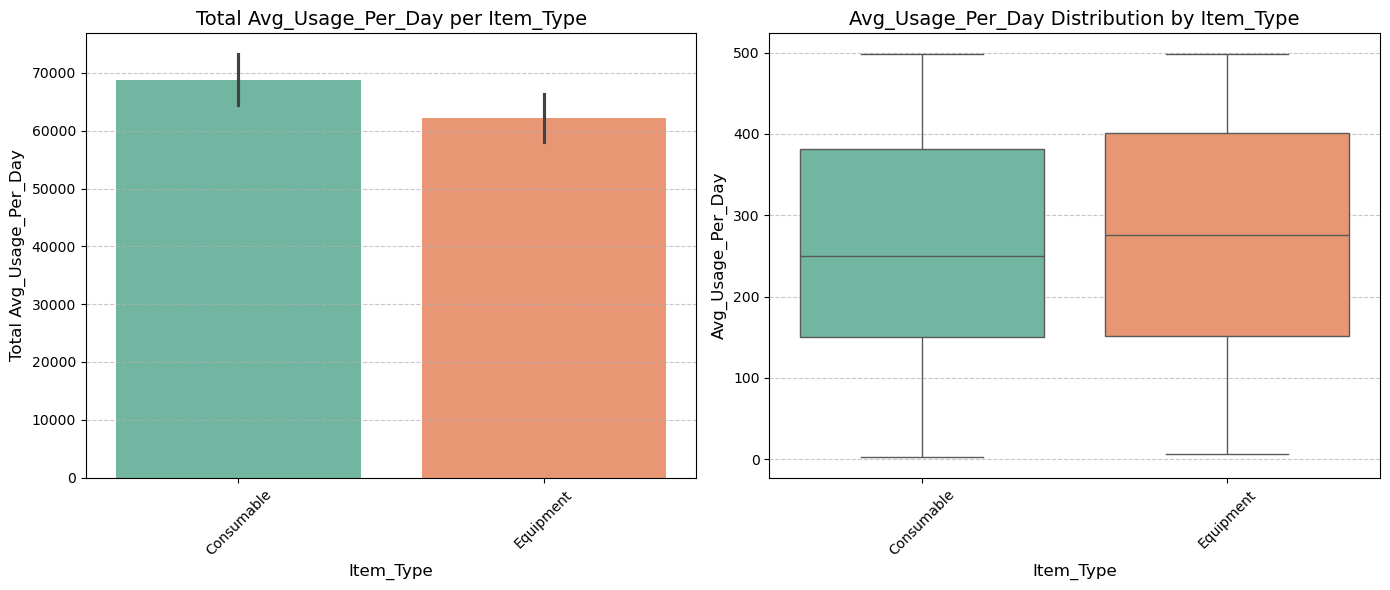

In [15]:
# how does the AVG. usage per day differ with the item type?

plt.figure(figsize=(14, 6))

# Subplot 1: Bar Chart (Average Avg_Usage_Per_Day per item type)
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Item_Type', y='Avg_Usage_Per_Day', estimator=sum, palette='Set2')
plt.title('Total Avg_Usage_Per_Day per Item_Type', fontsize=14)
plt.xlabel('Item_Type', fontsize=12)
plt.ylabel('Total Avg_Usage_Per_Day', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Boxplot (Avg_Usage_Per_Day Distribution per Item_Type)
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Item_Type', y='Avg_Usage_Per_Day', palette='Set2')
plt.title('Avg_Usage_Per_Day Distribution by Item_Type', fontsize=14)
plt.xlabel('Item_Type', fontsize=12)
plt.ylabel('Avg_Usage_Per_Day', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()

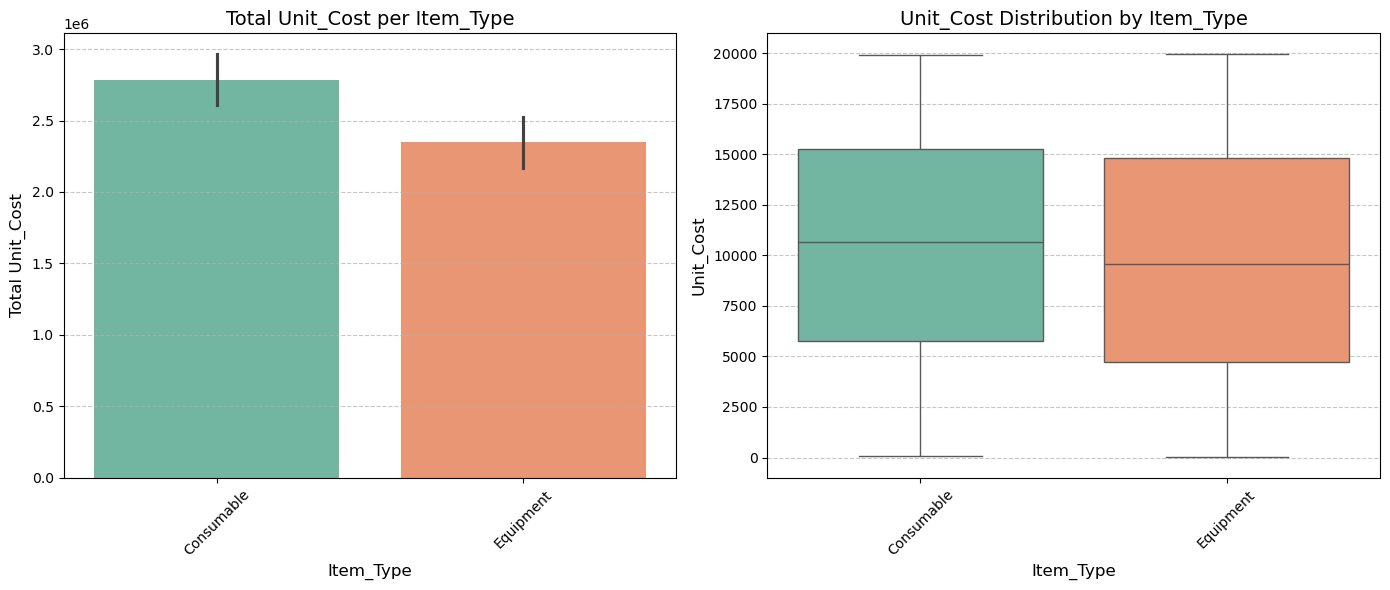

In [16]:
# how does the unit cost differ with the item type?

plt.figure(figsize=(14, 6))

# Subplot 1: Bar Chart (Average Unit_Cost per item type)
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Item_Type', y='Unit_Cost', estimator=sum, palette='Set2')
plt.title('Total Unit_Cost per Item_Type', fontsize=14)
plt.xlabel('Item_Type', fontsize=12)
plt.ylabel('Total Unit_Cost', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Boxplot (Unit_Cost Distribution per Item_Type)
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Item_Type', y='Unit_Cost', palette='Set2')
plt.title('Unit_Cost Distribution by Item_Type', fontsize=14)
plt.xlabel('Item_Type', fontsize=12)
plt.ylabel('Unit_Cost', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()

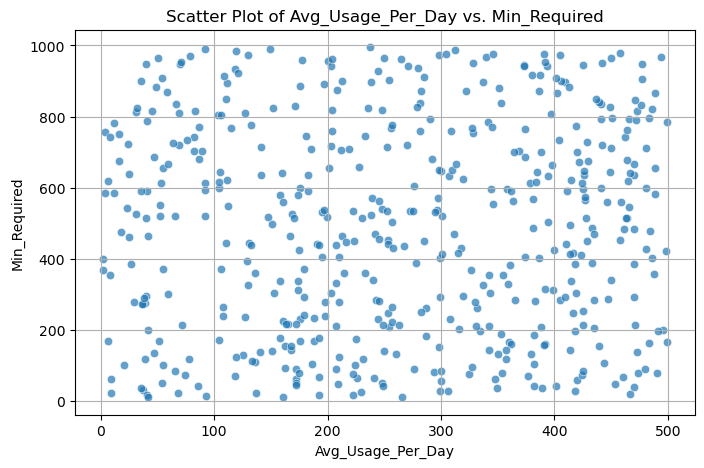

In [17]:
# is there a relation between AVG. usage per day and min. reguired quantity of the item?

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Avg_Usage_Per_Day", y="Min_Required", alpha=0.7)
plt.title("Scatter Plot of Avg_Usage_Per_Day vs. Min_Required")
plt.xlabel("Avg_Usage_Per_Day")
plt.ylabel("Min_Required")
plt.grid(True)
plt.show()

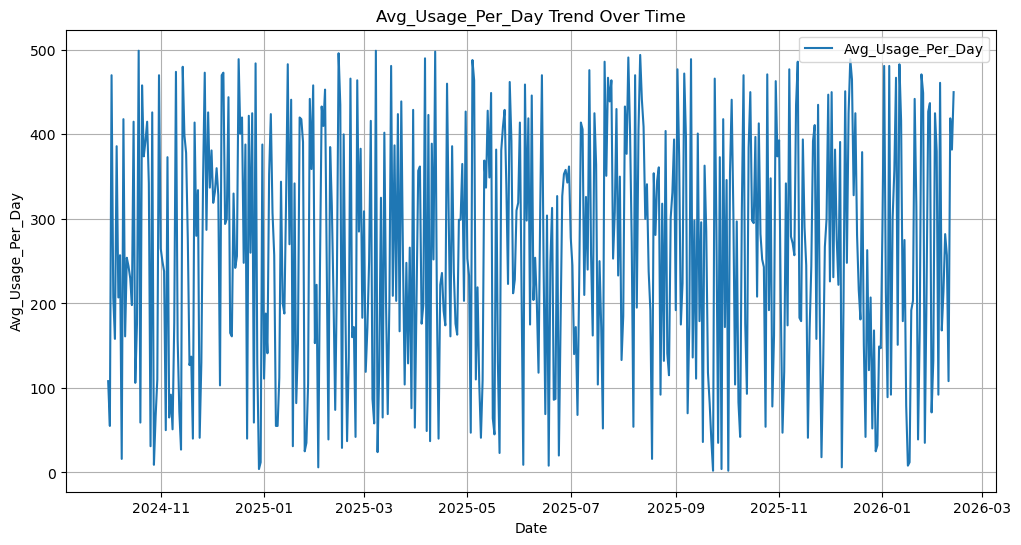

In [18]:
# Demand progress visualization
# Avg_Usage_Per_Day with the time

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)  # Set Date as the index
df = df.sort_index()  # Ensure the dataset is sorted by date

# Plot Avg_Usage_Per_Day Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Date", y="Avg_Usage_Per_Day", label="Avg_Usage_Per_Day")
plt.xlabel("Date")
plt.ylabel("Avg_Usage_Per_Day")
plt.title("Avg_Usage_Per_Day Trend Over Time")
plt.legend()
plt.grid(True)
plt.show()

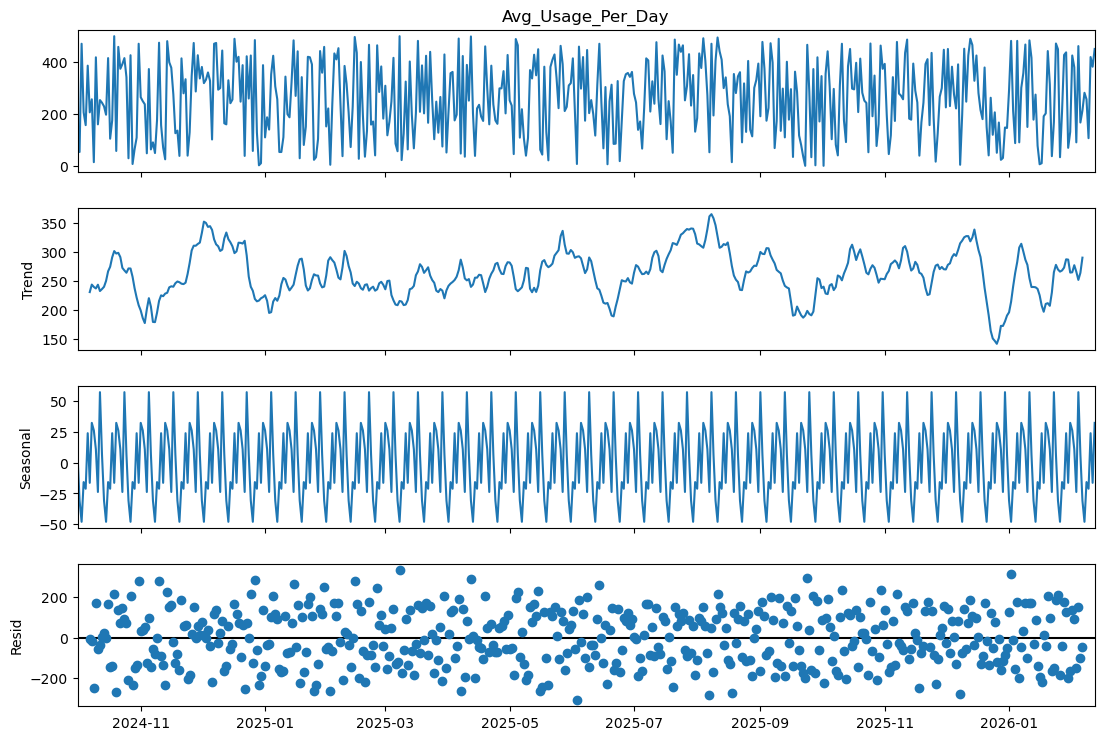

In [19]:
# Time Series Decomposition, Splits the time series into trend, seasonality, and residuals.

import statsmodels.api as sm

Avg_Usage = df['Avg_Usage_Per_Day']
decomposition = sm.tsa.seasonal_decompose(Avg_Usage, model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

Observed (First Plot - "Avg_Usage_Per_Day")

This is the original time series data of average usage per day.
The series appears to be highly fluctuating with visible ups and downs.

Trend (Second Plot)

This represents the long-term movement of the data.
it shows gradual upward and downward movements, indicating periods of increase and decrease in usage.

Seasonality (Third Plot)

This captures recurring patterns at regular intervals (e.g., daily, weekly, monthly).
The plot shows clear periodic oscillations, meaning there are repeating cycles in your data.
The fluctuations suggest the demand for medical items follows a predictable seasonal pattern.

Residual (Fourth Plot - Noise/Irregularities)

This is the remaining component after removing trend and seasonality, representing random noise.
The residuals are scattered around zero, meaning no obvious pattern remains.


In [20]:
# ADF Test for Stationarity, If p-value > 0.05, the series is non-stationary.

from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(Avg_Usage.dropna())  
print("ADF Test Statistic:", adf_test[0])
print("p-value:", adf_test[1])
print("Critical Values:", adf_test[4])

ADF Test Statistic: -22.41789147378155
p-value: 0.0
Critical Values: {'1%': -3.4435228622952065, '5%': -2.867349510566146, '10%': -2.569864247011056}


A p-value of 0  means that this time series is stationary at a very high confidence level.

I do not need to apply differencing and can directly proceed with modeling (e.g., SARIMA, Prophet, or other time series forecasting methods).

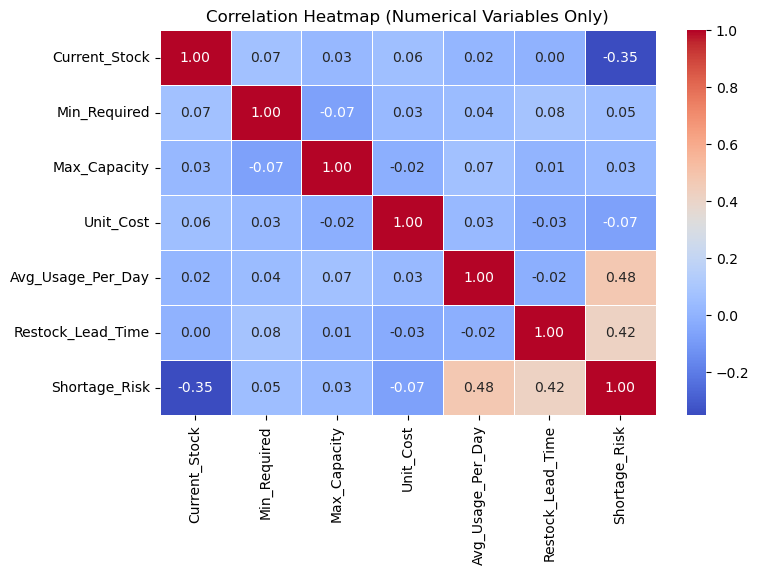

In [21]:
# correlation for all numeric variables
# Select only numerical columns
numerical_df = df.select_dtypes(include=['number'])

# Plot correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numerical Variables Only)")
plt.show()

<h1> Feature Engineering:-

In [22]:
# new feature: "Reorder_Point" based on EOQ (Economic Order Quantity) calculation 
# Reorder Point = (AVG. usage per day × Restock Lead Time) + Safety Stock 
# current stock must be > or = this reorder point to prevent shortage

df['Reorder_Point'] = (df['Avg_Usage_Per_Day'] * df['Restock_Lead_Time']) + (df['Min_Required'] * 0.5)


In [23]:
# new feature: "Need_More_space"
# I observed some rows with "current_stock" > "max_capacity" which may indicate overstocking risk. But because I also observed that some of these overstocking records 
# have shortage risk which is opposite to the overstocking case, I had to investigate more in this point
# Now I want to know if this dual observation is due to entry errors or it's ratio is too big to be assumed like that.

dual_obs = df[(df['Shortage_Risk'] == 1) & (df['Current_Stock'] > df['Max_Capacity'])]

dual_obs.shape[0]

100

In [24]:
# 100 rows represents 20% of the data which can't be assumed as entry errors. 
# the other assumption is that these dual observations are true and the most possible cause for them is that there is a real need for more space to be provided to stock.

# the next new feature:-

df['Need_More_Space'] = df['Max_Capacity'] < df['Reorder_Point']


In [25]:
df['Need_More_Space'] = df['Need_More_Space'].astype(int)

df.head()

,Item_Type,Current_Stock,Min_Required,Max_Capacity,Unit_Cost,Avg_Usage_Per_Day,Restock_Lead_Time,Shortage_Risk,Reorder_Point,Need_More_Space
Date,,,,,,,,,,
2024-10-01,Consumable,1542,264,1018,4467.55,108,17,1,1968.0,1
2024-10-02,Equipment,2487,656,3556,5832.29,55,12,0,988.0,0
2024-10-03,Equipment,2371,384,5562,16062.98,470,6,1,3012.0,0
2024-10-04,Consumable,2038,438,1131,744.10,207,15,1,3324.0,1
2024-10-05,Equipment,2410,338,1013,15426.53,158,12,0,2065.0,1


In [26]:
# encoding

unique_vals = df['Item_Type'].unique()
df['Item_Type'] = df['Item_Type'].replace({unique_vals[0]: 0, unique_vals[1]: 1})


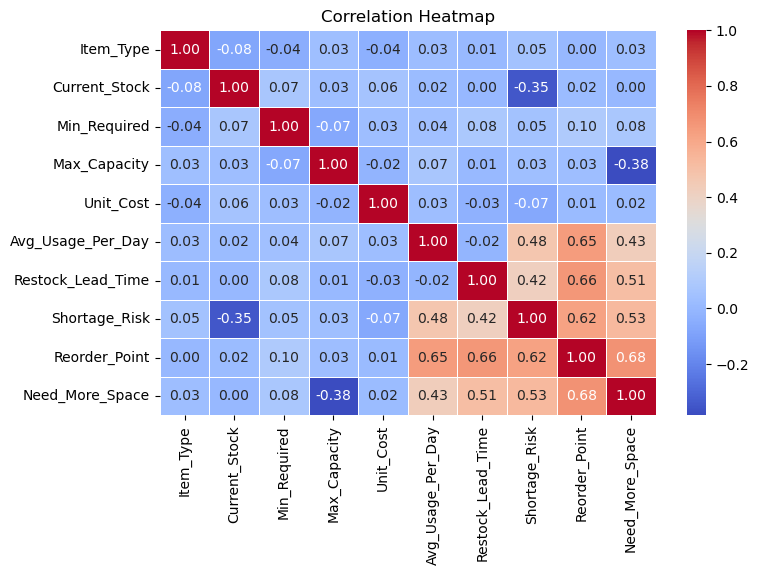

In [27]:
# Plot correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

<h1> Conclusion:-

I can follow 2 different ways in modeling this dataset:-

1 - Time series modeling for Avg_Usage_Per_Day prediction using Prophet or SARIMS models.

2 - Machine learning classification model to predict shortage risk as I have a very promising correlation scores.

In [28]:
df.to_csv('inventory_EDA.csv')

Columns documentation:-

Date: record capture date, valuable for time series analysis.

Item_Type: case type for the recorded item, consumable or equipment.

Current_Stock: the current available number of this specific item in the hospital stock.

Min_Required: represents the safety stock for this item, min. number must be available all the time.

Max_Capacity: the maximum number of this item stock can handle.

Unit_Cost: price for one unit of this item.

Avg_Usage_Per_Day: average number of units needed per day.

Restock_Lead_Time: no. of days left from the record date to the next restocking process date for this item as scheduled.